# CPE 342 Machine Learning — Assignment 2: Training Models
**Author:** 67070501042 วิศิษฐ์ สุวรรณเนาว์

## 1. Problem Overview
In this assignment, we use an **iterative approach** (Gradient Descent) to train a model and fit it to a dataset of 100 observations ($n=100$). 

The goal is to fit a quadratic model without a linear $x$ term:
$$ \hat{y} = C_0 + C_1 x^2 $$
Where:
- $C_0$ is the y-intercept (Bias)
- $C_1$ is the coefficient of $x^2$ (Slope of $x^2$)

## 2. Library & Font Setup
Loading libraries and downloading the Sarabun font to support Thai rendering in Matplotlib if needed.

In [1]:
# Download TH Sarabun New font for Matplotlib
!wget -q https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import urllib.request
import os

# Font configuration
font_path = 'thsarabunnew-webfont.ttf'
if not os.path.exists(font_path):
    urllib.request.urlretrieve('https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf', font_path)
fm.fontManager.addfont(font_path)
mpl.rc('font', family='TH Sarabun New', size=14)
mpl.rcParams['axes.unicode_minus'] = False # Prevent minus sign rendering issues

print("Library and font setup complete")

'wget' is not recognized as an internal or external command,
operable program or batch file.


Library and font setup complete


## 3. Data Loading & Exploratory Data Analysis (EDA)
Read the data from the CSV file and plot scatter plots to observe the relationship between $x$ and $y$.

,X,Y
0,4.072280,0.981321
1,1.724332,1.124653
2,1.901981,1.042435
3,4.914068,0.949332
4,1.165868,1.186925


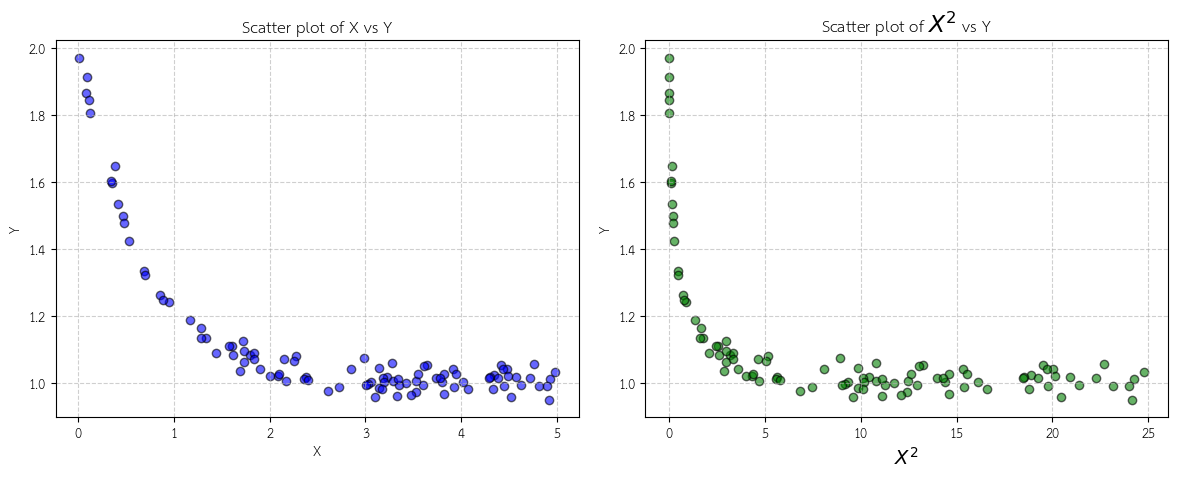

In [2]:
# Read data
df = pd.read_csv('CPE342_Assignment 2_Data.csv')
X = df['X'].values
Y = df['Y'].values

# Display first few rows
display(df.head())

# Plot graphs to observe trends
plt.figure(figsize=(12, 5))

# Plot X vs Y
plt.subplot(1, 2, 1)
plt.scatter(X, Y, color='blue', alpha=0.6, edgecolor='k')
plt.title('Scatter plot of X vs Y')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True, linestyle='--', alpha=0.6)

# Plot X^2 vs Y
plt.subplot(1, 2, 2)
plt.scatter(X**2, Y, color='green', alpha=0.6, edgecolor='k')
plt.title('Scatter plot of $X^2$ vs Y')
plt.xlabel('$X^2$')
plt.ylabel('Y')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Task 1 — Loss Function
Given our model $\hat{y}_i = C_0 + C_1 x_i^2$, 

The loss function we use is the **Mean Squared Error (MSE)**, which computes the average squared differences (residuals) across all data points:

$$ L(C_0, C_1) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $$

Substituting $\hat{y}_i$ gives our target equation:
$$ L(C_0, C_1) = \frac{1}{n} \sum_{i=1}^{n} (y_i - C_0 - C_1 x_i^2)^2 $$

## Task 2 — Gradient of Each Coefficient
To compute the gradients of the loss function $L$ with respect to each parameter ($C_0$ and $C_1$), we apply the **chain rule**. 

For any coefficient $\theta$, the partial derivative is:
$$ \frac{\partial L}{\partial \theta} = \frac{\partial}{\partial \theta} \left[ \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 \right] $$
$$ = \frac{1}{n} \sum_{i=1}^{n} 2(y_i - \hat{y}_i) \cdot \frac{\partial}{\partial \theta}(y_i - \hat{y}_i) $$
$$ = -\frac{2}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i) \cdot \frac{\partial \hat{y}_i}{\partial \theta} $$

---
### 1. Gradient with respect to $C_0$:
First, find $\frac{\partial \hat{y}_i}{\partial C_0}$:
$$ \hat{y}_i = C_0 + C_1 x_i^2 $$
$$ \frac{\partial \hat{y}_i}{\partial C_0} = \frac{\partial}{\partial C_0}(C_0 + C_1 x_i^2) = 1 + 0 = 1 $$

Substituting this back into the chain rule formula:
$$ \frac{\partial L}{\partial C_0} = -\frac{2}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i) \cdot 1 $$
$$ \frac{\partial L}{\partial C_0} = -\frac{2}{n} \sum_{i=1}^{n} (y_i - C_0 - C_1 x_i^2) $$

---
### 2. Gradient with respect to $C_1$:
To minimize the loss function, we calculate the partial derivatives (gradients) with respect to each parameter using the chain rule:

1. **Gradient with respect to $C_0$:**
$$ \frac{\partial L}{\partial C_0} = -\frac{1}{n} \sum_{i=1}^{n} \left( y_i - \hat{y}_i \right) $$

2. **Gradient with respect to $C_1$:**
$$ \frac{\partial L}{\partial C_1} = -\frac{1}{n} \sum_{i=1}^{n} \left( y_i - \hat{y}_i \right) e^{C_2 x_i} $$

3. **Gradient with respect to $C_2$:**
$$ \frac{\partial L}{\partial C_2} = -\frac{1}{n} \sum_{i=1}^{n} \left( y_i - \hat{y}_i \right) C_1 x_i e^{C_2 x_i} $$

## Task 3 — Update Rules
In each iteration of Gradient Descent, the parameters are updated by moving in the opposite direction of the gradient, scaled by the learning rate $\eta$:

$$ C_0^{(t+1)} = C_0^{(t)} - \eta \frac{\partial L}{\partial C_0} $$
$$ C_1^{(t+1)} = C_1^{(t)} - \eta \frac{\partial L}{\partial C_1} $$
$$ C_2^{(t+1)} = C_2^{(t)} - \eta \frac{\partial L}{\partial C_2} $$

## Task 4 — Gradient Descent Implementation
We will now implement the algorithm in Python. 
We set our learning rate $\eta = 1.0$, `max_iterations = 2000`, and initialized parameters as $C_0=0.5, C_1=0.5, C_2=0.1$.

In [3]:
# Initialize hyperparameters
learning_rate = 1.0
max_iterations = 2000
tolerance = 1e-6

# Initialize coefficients
C0, C1, C2 = 0.5, 0.5, 0.1
n = len(X)

# Lists to store history for visualization
history_loss = []
history_C0, history_C1, history_C2 = [], [], []

# Gradient Descent Loop
for i in range(max_iterations):
    # Calculate predictions using the exponential model
    exp_term = np.exp(C2 * X)
    Y_pred = C0 + C1 * exp_term
    
    # Calculate Error
    error = Y - Y_pred
    
    # Calculate MSE Loss (using 1/(2n))
    loss = (1 / (2 * n)) * np.sum(error**2)
    
    # Store history
    history_loss.append(loss)
    history_C0.append(C0)
    history_C1.append(C1)
    history_C2.append(C2)
    
    # Calculate Gradients
    grad_C0 = -(1 / n) * np.sum(error)
    grad_C1 = -(1 / n) * np.sum(error * exp_term)
    grad_C2 = -(1 / n) * np.sum(error * C1 * X * exp_term)
    
    # Update coefficients
    C0 -= learning_rate * grad_C0
    C1 -= learning_rate * grad_C1
    C2 -= learning_rate * grad_C2
    
    # Early stopping condition
    if i > 0 and abs(history_loss[-1] - history_loss[-2]) < tolerance:
        print(f"Converged at iteration {i}")
        break

print(f"Training completed in {len(history_loss)} iterations.")
print(f"Final Parameters: C0 = {C0:.4f}, C1 = {C1:.4f}, C2 = {C2:.4f}")
print(f"Final MSE Loss: {history_loss[-1]:.4f}")

Converged at iteration 269
Training completed in 270 iterations.
Final Parameters: C0 = 0.9927, C1 = 0.9587, C2 = -1.3296
Final MSE Loss: 0.0005


## Task 5 — Results & Visualizations
In this section, we analyze the behavior of our trained model and evaluate how well it fits the dataset using various plots.

<>:26: SyntaxWarning: invalid escape sequence '\h'
<>:39: SyntaxWarning: invalid escape sequence '\h'
<>:26: SyntaxWarning: invalid escape sequence '\h'
<>:39: SyntaxWarning: invalid escape sequence '\h'
C:\Users\Admin\AppData\Local\Temp\ipykernel_22544\1694607884.py:26: SyntaxWarning: invalid escape sequence '\h'
  ax3.plot(x_line, y_line, 'r-', linewidth=3, label=f'Fitted Model: $\hat{{y}} = {C0:.2f} + {C1:.2f}e^{{{C2:.2f}x}}$')
C:\Users\Admin\AppData\Local\Temp\ipykernel_22544\1694607884.py:39: SyntaxWarning: invalid escape sequence '\h'
  ax4.set_ylabel('Residuals ($y_i - \hat{y}_i$)')


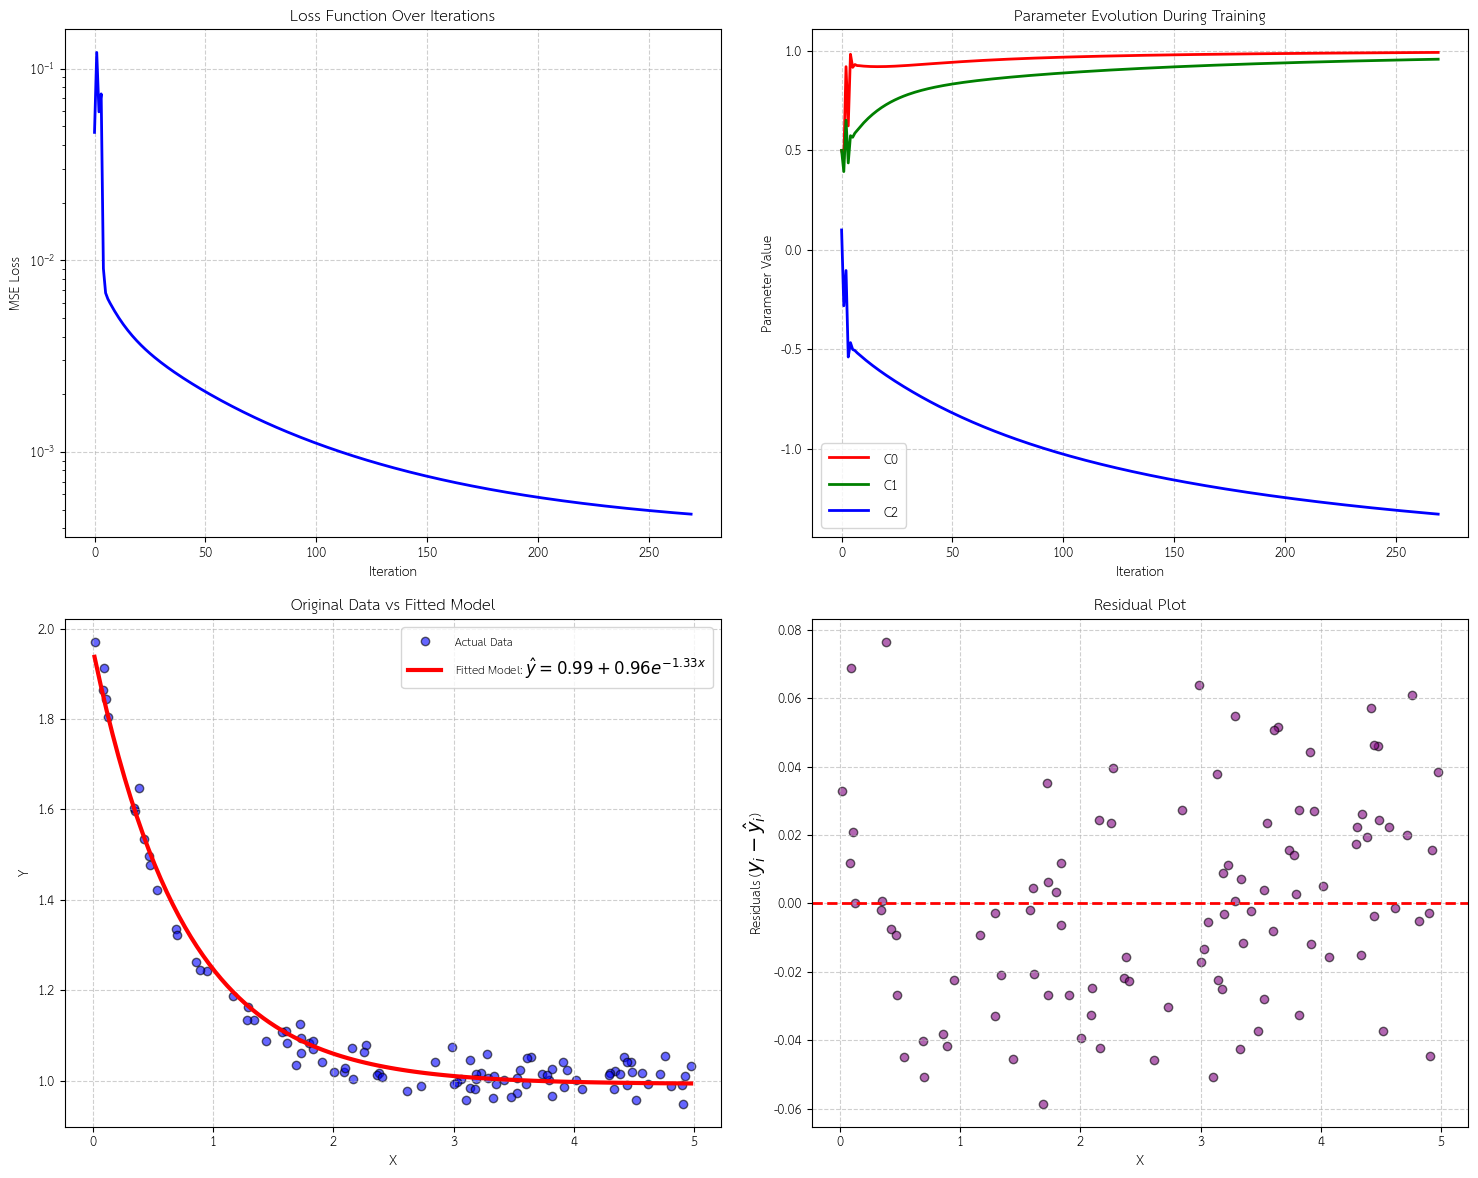

In [4]:
# Create subplots for a 2x2 grid visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Learning Curve (Loss over Iterations)
ax1.plot(range(len(history_loss)), history_loss, 'b-', linewidth=2)
ax1.set_xlabel('Iteration')
ax1.set_ylabel('MSE Loss')
ax1.set_title('Loss Function Over Iterations')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.set_yscale('log') # Log scale to see convergence better

# Plot 2: Convergence of parameters
ax2.plot(range(len(history_C0)), history_C0, 'r-', label='C0', linewidth=2)
ax2.plot(range(len(history_C1)), history_C1, 'g-', label='C1', linewidth=2)
ax2.plot(range(len(history_C2)), history_C2, 'b-', label='C2', linewidth=2)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Parameter Value')
ax2.set_title('Parameter Evolution During Training')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

# Plot 3: Fitted Curve vs Actual Data
x_line = np.linspace(min(X), max(X), 100)
y_line = C0 + C1 * np.exp(C2 * x_line)
ax3.scatter(X, Y, color='blue', alpha=0.6, label='Actual Data', edgecolor='k')
ax3.plot(x_line, y_line, 'r-', linewidth=3, label=f'Fitted Model: $\hat{{y}} = {C0:.2f} + {C1:.2f}e^{{{C2:.2f}x}}$')
ax3.set_xlabel('X')
ax3.set_ylabel('Y')
ax3.set_title('Original Data vs Fitted Model')
ax3.legend(fontsize=12)
ax3.grid(True, linestyle='--', alpha=0.6)

# Plot 4: Residuals
Y_pred_final = C0 + C1 * np.exp(C2 * X)
residuals = Y - Y_pred_final
ax4.scatter(X, residuals, color='purple', alpha=0.6, edgecolor='k')
ax4.axhline(0, color='red', linestyle='--', linewidth=2)
ax4.set_xlabel('X')
ax4.set_ylabel('Residuals ($y_i - \hat{y}_i$)')
ax4.set_title('Residual Plot')
ax4.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Task 6 — Model Evaluation (R-squared & Summary Statistics)
To mathematically evaluate the goodness of fit for our machine learning model, we calculate the Coefficient of Determination, also known as $R^2$.

The formula for $R^2$ is:
$$ R^2 = 1 - \frac{SS_{res}}{SS_{tot}} $$

Where:
- **Residual Sum of Squares ($SS_{res}$)** is the sum of the squared differences between the actual and predicted values:
$$ SS_{res} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $$
- **Total Sum of Squares ($SS_{tot}$)** is the sum of the squared differences between the actual values and the mean of the actual values ($\bar{y}$):
$$ SS_{tot} = \sum_{i=1}^{n} (y_i - \bar{y})^2 $$

A higher $R^2$ score (closer to 1) indicates that our model's predictions closely match the actual data points.

In [5]:
# Print summary statistics
print("\n=== MODEL EVALUATION SUMMARY ===")
print(f"Fitted parameters: C0 = {C0:.6f}, C1 = {C1:.6f}, C2 = {C2:.6f}")
print(f"Total Iterations: {len(history_loss)}")
print(f"Initial loss: {history_loss[0]:.6f}")
print(f"Final loss: {history_loss[-1]:.6f}")
loss_reduction = (history_loss[0] - history_loss[-1]) / history_loss[0] * 100
print(f"Loss reduction: {loss_reduction:.2f}%")

# Calculate R-squared
Y_mean = np.mean(Y)
ss_res = np.sum((Y - Y_pred_final)**2)
ss_tot = np.sum((Y - Y_mean)**2)
r_squared = 1 - (ss_res / ss_tot)
print(f"R-squared (R^2): {r_squared:.6f}")


=== MODEL EVALUATION SUMMARY ===
Fitted parameters: C0 = 0.992665, C1 = 0.958671, C2 = -1.329637
Total Iterations: 270
Initial loss: 0.046463
Final loss: 0.000474
Loss reduction: 98.98%
R-squared (R^2): 0.981770
